A partir de las medidas realizadas en Castellón y Alcobendas se compararan los resultados obtenidos por el sistema de medición movíl para diferentes velocidades y estados del pavimento 

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Gis pkgs
import geopandas as gpd
import overpass
import shapely
from shapely.geometry import Point, LineString, Polygon, MultiPoint

plt.style.use("bmh")

In [3]:
def get_filt_df(df):
    speed_diff = np.diff(df["speed"])
    speed_diff = np.insert(speed_diff,0,0)

    df["speed_diff"] = np.abs(speed_diff)
    df = df[df["speed_diff"].between(0,10)].copy()
    df["speed_diff_range"]  = pd.cut(df["speed_diff"],bins=5)

    df_filt = df[df["speed_diff"].between(-1,1)].copy()
    return df_filt

In [4]:
df_alcobendas = pd.read_csv("pavimentos_alcobendas.csv")
df_alcobendas["ciudad"] = "alcobendas"
df_castellon_dia = pd.read_csv("pavimentos_Castellon_17Nov_Tarde.csv")
df_castellon_dia["ciudad"] = "castellon"
df_castellon_noche = pd.read_csv("pavimentos_Castellon_17Nov_Noche.csv")
df_castellon_noche["ciudad"] = "castellon"

df_all = pd.DataFrame()
for df in [df_alcobendas,df_castellon_dia,df_castellon_noche]:
    df_all = pd.concat([df_all,df])
    

## Alcobendas

Al el histograma de las velocidades se pueden obervar diferentes agrupaciones de velocidad, la mayoria para velocidades cercanas a 0 que corresponden con los periodos en donde el coche esta parado. dos agrupaciones cercanas a 30km/h y otra en 50 km/h


Text(0.5, 0, 'Velocidad km/h')

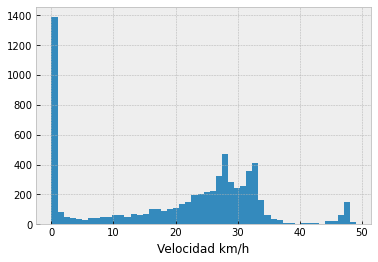

In [5]:
df_alcobendas["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h")

Al filtrar las velocidades mayores a 10 km/h se observa la distribución en donde se evidencia que el recorrido se hizo en su mayoria a velocidades de 30km/h

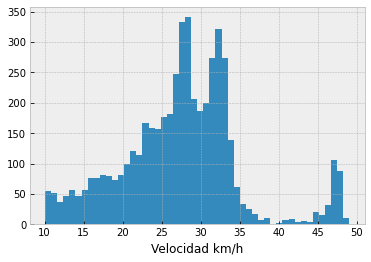

In [6]:
df_alcobendas = df_alcobendas[df_alcobendas["speed"] > 10].copy()
df_alcobendas["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h");

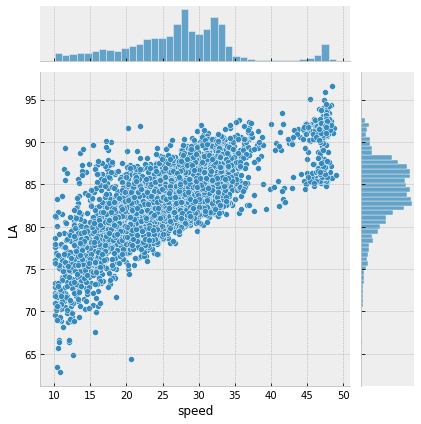

In [7]:
sns.jointplot(data=df_alcobendas, x="speed", y="LA");
plt.xlabel("Velocidad km/h");
plt.ylabel("dB(A)");

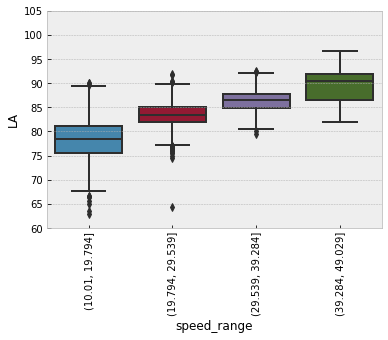

In [8]:
df_alcobendas["speed_range"] = pd.cut(df_alcobendas["speed"],bins=4)
sns.boxplot(data=df_alcobendas,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);

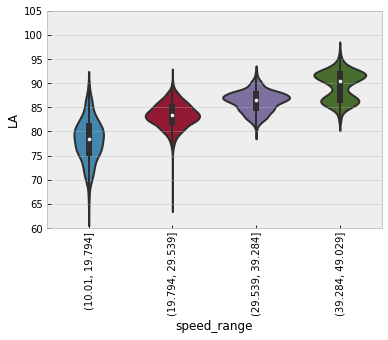

In [9]:
df_alcobendas["speed_range"] = pd.cut(df_alcobendas["speed"],bins=4)
sns.violinplot(data=df_alcobendas,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);

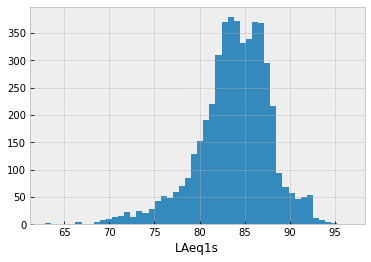

In [10]:
df_alcobendas["LA"].hist(bins=50)
plt.xlabel("LAeq1s");

In [11]:


mod = smf.ols(formula='LA ~ np.log10(speed)', data=df_alcobendas)
res = mod.fit()
print(res.summary())
print(res.params)

                            OLS Regression Results                            
Dep. Variable:                     LA   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     7311.
Date:                Wed, 30 Nov 2022   Prob (F-statistic):               0.00
Time:                        12:00:57   Log-Likelihood:                -11789.
No. Observations:                4969   AIC:                         2.358e+04
Df Residuals:                    4967   BIC:                         2.359e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          49.9018      0.399    1

C:\Users\CALC_C~1\AppData\Local\Temp/ipykernel_17740/1845051574.py:3: RuntimeWarning: divide by zero encountered in log10
  fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)


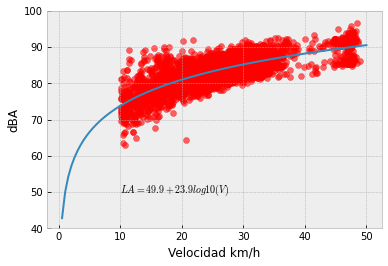

In [12]:
res_params = res.params
speed_vec = np.linspace(0,50,100)
fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)

plt.scatter(df_alcobendas["speed"], df_alcobendas["LA"],color="red",alpha=0.6)
plt.text(10,50,f"$LA = {round(res_params[0],1)} + {round(res_params[1],1)}log10(V)$")
plt.plot(speed_vec,fit_model)
plt.ylim([40,100])
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

## Correción por efecto de velocidad

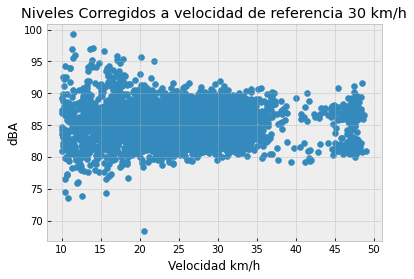

In [18]:
LA_corrected = df_alcobendas["LA"] - res_params[1]*np.log10(df_alcobendas["speed"]/30)
plt.scatter(df_alcobendas["speed"],LA_corrected)
plt.title("Niveles Corregidos a velocidad de referencia 30 km/h");
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

## regresiòn filtrada

In [119]:
df_filt = get_filt_df(df)
df_filt.dropna(subset=["LA"],inplace=True)

mod = smf.ols(formula='LA ~ np.log10(speed)', data=df_filt)
res = mod.fit()
print(res.summary())
print(res.params)

                            OLS Regression Results                            
Dep. Variable:                     LA   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 24 Nov 2022   Prob (F-statistic):                nan
Time:                        15:26:09   Log-Likelihood:                    nan
No. Observations:                4810   AIC:                               nan
Df Residuals:                    4810   BIC:                               nan
Df Model:                          -1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept              nan        nan     

C:\Users\CALC_COLOMBIA\anaconda3\lib\site-packages\pandas\core\arraylike.py:364: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Castellon dia


Text(0.5, 0, 'Velocidad km/h')

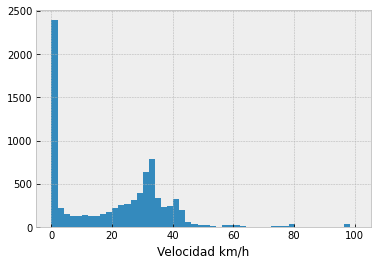

In [85]:
df_castellon_dia["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h")

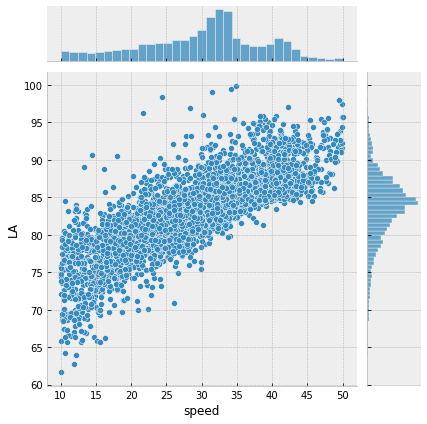

In [49]:
sns.jointplot(data=df_castellon_dia, x="speed", y="LA",hue);
plt.xlabel("Velocidad km/h");
plt.ylabel("dB(A)");

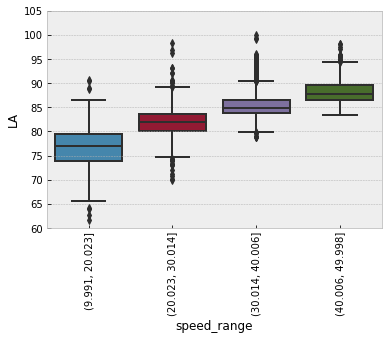

In [126]:
df_castellon_dia = df_castellon_dia[df_castellon_dia["speed"] > 10].copy()
df_castellon_dia = df_castellon_dia[df_castellon_dia["speed"] < 50].copy()

df_castellon_dia["speed_range"] = pd.cut(df_castellon_dia["speed"],bins=4)
sns.boxplot(data=df_castellon_dia,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);

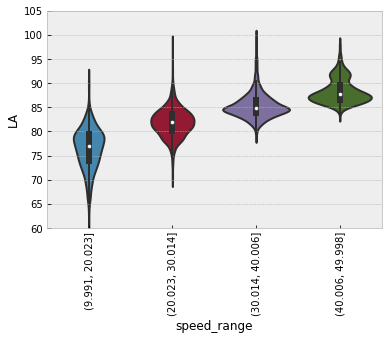

In [133]:

sns.violinplot(data=df_castellon_dia,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);

In [180]:
mod = smf.ols(formula='LA ~ np.log10(speed)', data=df_castellon_dia)
res = mod.fit()
print(res.summary())
print(res.params)

                            OLS Regression Results                            
Dep. Variable:                     LA   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     9437.
Date:                Fri, 25 Nov 2022   Prob (F-statistic):               0.00
Time:                        11:27:03   Log-Likelihood:                -12262.
No. Observations:                5080   AIC:                         2.453e+04
Df Residuals:                    5078   BIC:                         2.454e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          45.9318      0.389    1

C:\Users\CALC_C~1\AppData\Local\Temp/ipykernel_16732/3586843237.py:4: RuntimeWarning: divide by zero encountered in log10
  fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)


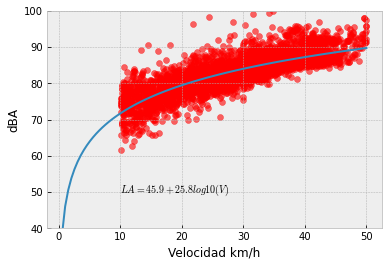

In [181]:
res_params = res.params

speed_vec = np.linspace(0,50,100)
fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)

plt.scatter(df_castellon_dia["speed"],df_castellon_dia["LA"],color="red",alpha=0.6)
plt.text(10,50,f"$LA = {round(res_params[0],1)} + {round(res_params[1],1)}log10(V)$")
plt.plot(speed_vec,fit_model)
plt.ylim([40,100])
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

In [ ]:
LA_corrected = df_castellon_noche["LA"] - 23.9*np.log10(df_castellon_noche["speed"]/30)
plt.scatter(df_castellon_noche["speed"],LA_corrected)

## Variación velocidad

In [87]:
speed_diff = np.diff(df_castellon_dia["speed"])
speed_diff = np.insert(speed_diff,0,0)

df_castellon_dia["speed_diff"] = np.abs(speed_diff)
df_castellon_dia = df_castellon_dia[df_castellon_dia["speed_diff"].between(0,10)].copy()
df_castellon_dia["speed_diff_range"]  = pd.cut(df_castellon_dia["speed_diff"],bins=5)

df_castellon_dia_filt = df_castellon_dia[df_castellon_dia["speed_diff"].between(-1,1)].copy()

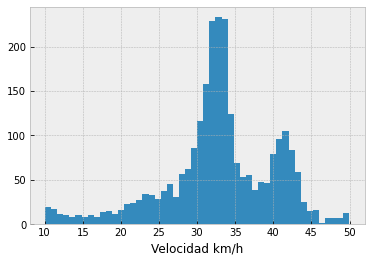

In [88]:
df_castellon_dia_filt["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h");

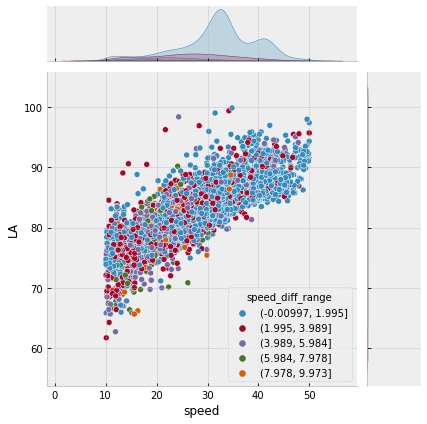

In [89]:
sns.jointplot(data=df_castellon_dia, x="speed", y="LA",hue="speed_diff_range");
plt.xlim([0,50])
plt.xlabel("Velocidad km/h");
plt.ylabel("dB(A)");

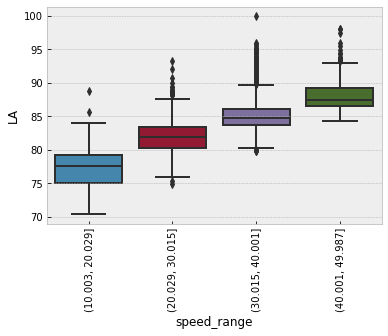

In [70]:
df_castellon_dia_filt = df_castellon_dia_filt[df_castellon_dia_filt["speed"] > 10].copy()
df_castellon_dia_filt = df_castellon_dia_filt[df_castellon_dia_filt["speed"] < 50].copy()

df_castellon_dia_filt["speed_range"] = pd.cut(df_castellon_dia_filt["speed"],bins=4)
sns.boxplot(data=df_castellon_dia_filt,x="speed_range",y="LA")
plt.xticks(rotation=90);

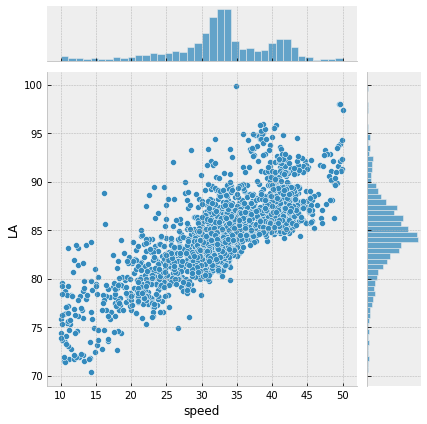

In [71]:
sns.jointplot(data=df_castellon_dia_filt, x="speed", y="LA");
plt.xlabel("Velocidad km/h");
plt.ylabel("dB(A)");

(-10.0, 10.0)

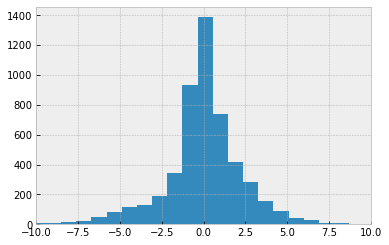

In [63]:
plt.hist(np.diff(df_castellon_dia["speed"]),bins=50);
plt.xlim([-10,10])

## Castellon noche

Text(0.5, 0, 'Velocidad km/h')

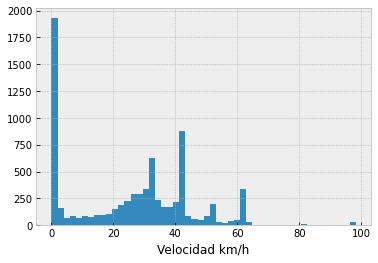

In [122]:
df_castellon_noche["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h")

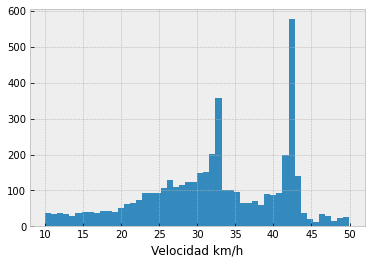

In [124]:
df_castellon_noche = df_castellon_noche[df_castellon_noche["speed"] > 10].copy()
df_castellon_noche = df_castellon_noche[df_castellon_noche["speed"] < 50].copy()
df_castellon_noche["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h");

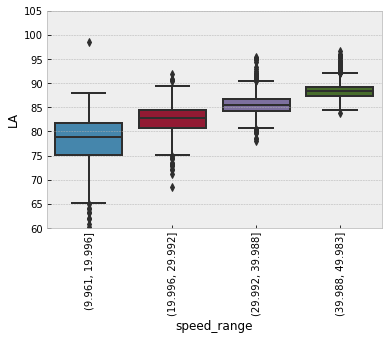

In [127]:
df_castellon_noche = df_castellon_noche[df_castellon_noche["speed"] > 10].copy()
df_castellon_noche = df_castellon_noche[df_castellon_noche["speed"] < 50].copy()

df_castellon_noche["speed_range"] = pd.cut(df_castellon_noche["speed"],bins=4)
sns.boxplot(data=df_castellon_noche,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);

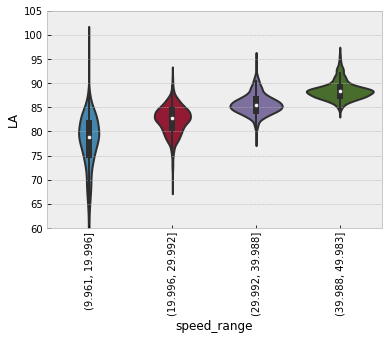

In [134]:
sns.violinplot(data=df_castellon_noche,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);

In [183]:
mod = smf.ols(formula='LA ~ np.log10(speed)', data=df_castellon_noche)
res = mod.fit()
print(res.summary())
print(res.params)

                            OLS Regression Results                            
Dep. Variable:                     LA   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     6856.
Date:                Fri, 25 Nov 2022   Prob (F-statistic):               0.00
Time:                        11:28:23   Log-Likelihood:                -10826.
No. Observations:                4478   AIC:                         2.166e+04
Df Residuals:                    4476   BIC:                         2.167e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          49.7402      0.425    1

C:\Users\CALC_C~1\AppData\Local\Temp/ipykernel_16732/270583229.py:3: RuntimeWarning: divide by zero encountered in log10
  fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)


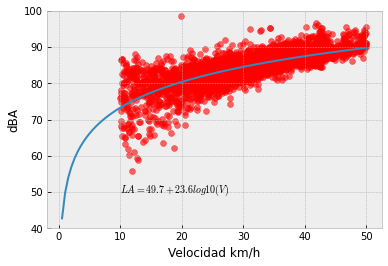

In [184]:
res_params = res.params
speed_vec = np.linspace(0,50,100)
fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)

plt.scatter(df_castellon_noche["speed"], df_castellon_noche["LA"],color="red",alpha=0.6)
plt.text(10,50,f"$LA = {round(res_params[0],1)} + {round(res_params[1],1)}log10(V)$")
plt.plot(speed_vec,fit_model)
plt.ylim([40,100])
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

In [233]:
i = 5
print(df_castellon_noche["speed"].iloc[i])
print(df_castellon_noche["LA"].iloc[i])
print(df_castellon_noche["LA"].iloc[i] + 23.9*(np.log10(30)) - 23.9*np.log10(df_castellon_noche["speed"].iloc[i]))
49.7 + 23.9*(np.log10(35/30)) 

20.876
78.7
82.46362780021612


51.30002827217166

In [232]:
23.9*(np.log10(25/30)) 

-1.8924317805382327

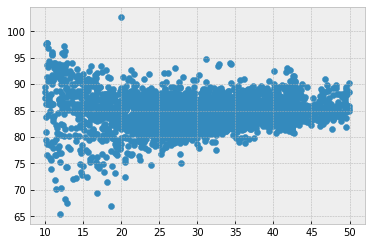

In [229]:
LA_corrected = df_castellon_noche["LA"] - 23.9*np.log10(df_castellon_noche["speed"]/30)
plt.scatter(df_castellon_noche["speed"],LA_corrected)

In [209]:
print(49.1 + 23.9*np.log10(30))
print(49.1 + 23.9*np.log10(35))

84.40319798779993
86.0032262599716


In [213]:
 np.log10(30)/np.log10(35)

80.7406346854349

## Todas las mediciones

ValueError: cannot reindex from a duplicate axis

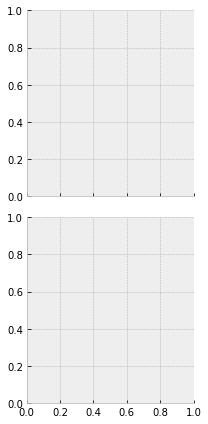

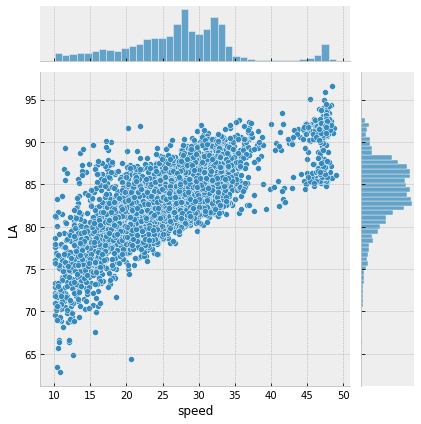

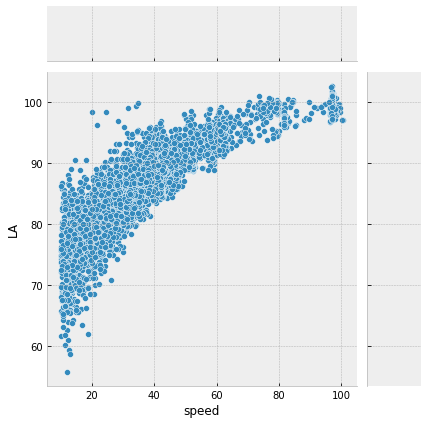

In [26]:
df_all = df_all[df_all["speed"] > 10].copy()
g = sns.FacetGrid(df_all, row="ciudad")
g.map(sns.jointplot, "speed", "LA")